# Proyecto 1: EDA Honesto, Feature Engineering y Baseline k-NN

**Ciencia de Datos, Sección A** · Segundo Semestre 2026  
**Autor:** Josué Aguilar  
**Dataset elegido:** Censo completo del RMS Titanic (`titanic5.xlsx - Titanic5_all.csv`)  
**Archivo final:** `P1-Aguilar.ipynb`  

---

### Rúbrica resumida

| Criterio | Pts | Qué buscamos |
|---|---|---|
| Pregunta y datos | 2 | Pregunta clara, provenance del dataset |
| EDA | 3 | Hallazgos, no galería de gráficas |
| Features | 2 | Cada decisión justificada, sin leakage |
| Baseline | 2 | Validación correcta, métrica adecuada |
| Límites | 1 | Qué no puede concluirse con estos datos |

## 1. Pregunta y contexto

El naufragio del RMS Titanic en abril de 1912 constituye uno de los eventos marítimos y sociológicos más documentados de la historia moderna. Tradicionalmente, los análisis predictivos sobre este desastre se han restringido a subconjuntos de pasajeros civiles, omitiendo el papel determinante de la tripulación técnica y de servicio, o asumiendo homogeneidad en los protocolos de salvamento. Sin embargo, la evacuación estuvo regida por tensiones estructurales: la directiva marítima de "mujeres y niños primero", la proximidad física a la cubierta superior según la tarifa abonada y la asignación laboral de emergencia de los miembros de la tripulación.

Este análisis busca responder: ¿con qué grado de certeza es posible estimar la probabilidad de supervivencia de un tripulante o pasajero del Titanic utilizando únicamente atributos demográficos, puerto de embarque, estructura familiar y rol funcional a bordo (`Class/Dept`), y en qué medida este modelo refleja la disparidad en la ejecución del protocolo de evacuación entre las distintas clases sociales y departamentos operativos?

Esta respuesta resulta de alto valor para historiadores cuantitativos, sociólogos de catástrofes y analistas de gestión de riesgos y seguridad humana. Permite determinar con rigor empírico si los patrones de supervivencia obedecieron primariamente a normas de caballería socialmente prescritas, a jerarquías socioeconómicas institucionalizadas o al rol logístico asignado durante la emergencia. Si la evidencia demostrara que el rol operativo y la clase social condicionaron la supervivencia por encima de los factores demográficos universales, se confirmaría que las emergencias no anulan las desigualdades preexistentes, sino que las exacerban bajo la apariencia de protocolos neutrales.

**Pregunta central:** ¿Con qué grado de certeza es posible estimar la probabilidad de supervivencia de un tripulante o pasajero del Titanic utilizando únicamente atributos demográficos, puerto de embarque, estructura familiar y rol funcional a bordo (`Class/Dept`), y en qué medida este modelo refleja la disparidad en la ejecución del protocolo de evacuación entre las distintas clases sociales y departamentos operativos?

**Tipo de problema:** Clasificación binaria supervisada.

**Variable objetivo:** `Survived` (0 = No sobrevivió / Fallecido, 1 = Sobrevivió).

## 2. Los datos

- **Fuente:** Repositorio de Datos de Bioestadística (Hbiostat Data Repository), compilado a partir de los registros de la *Encyclopedia Titanica*.
- **URL de origen:** [https://hbiostat.org/data/repo/titanic5](https://hbiostat.org/data/repo/titanic5)
- **Archivo analizado:** `titanic5.xlsx - Titanic5_all.csv` (2,208 registros censales).
- **Fecha de descarga local:** Septiembre de 2026.
- **Licencia:** Datos de dominio público para investigación académica.
- **Unidad de observación:** Cada registro individual representa a una persona única que se encontraba formalmente a bordo del RMS Titanic al momento del siniestro (total: 2,208 registros censales completos entre pasajeros de todas las clases y personal de todas las áreas de servicio y oficiales).

### Diccionario preliminar de variables

| Variable | Tipo conceptual | Descripción |
|---|---|---|
| `Name_ID` | Identificador | Clave numérica única de la persona en el registro |
| `Name`, `First`, `Last` | Texto | Nombre completo y apellidos del individuo |
| `Sex`, `Female`, `Male` | Categórica / Binaria | Sexo biológico reportado en el manifiesto |
| `Age`, `Age_F`, `Age_F_Code` | Numérica / Texto | Edad registrada en años y códigos de aproximación |
| `Class/Dept` | Categórica | Rol funcional a bordo (1st, 2nd, 3rd Class, Deck Crew, Engineering Crew, Victualling Crew, Restaurant Staff, Band) |
| `Class` | Categórica / Numérica | Indicador simplificado de clase de pasaje |
| `Ticket` | Alfanumérico | Número de boleto comercial (disponible en pasaje civil) |
| `Price` | Numérico / Texto | Tarifa pagada expresada en formato de libras esterlinas históricas |
| `Joined` | Categórica | Puerto donde abordó el barco (Southampton, Cherbourg, Queenstown, Belfast) |
| `Job`, `Occupation` | Texto | Ocupación laboral o función específica reportada |
| `DoB`, `DoB_Clean`, `Year_Birth` | Fecha / Numérica | Fecha y año de nacimiento |
| `Date_Death` | Fecha | Fecha de fallecimiento registrada |
| `Boat [Body]` | Alfanumérico | Identificador del bote salvavidas de rescate o número de cuerpo recuperado |
| `URL` | Texto | Enlace a la ficha biográfica de Encyclopedia Titanica |
| `sibsp` | Numérica entera | Número de cónyuges, hermanos y hermanas a bordo |
| `parch` | Numérica entera | Número de padres e hijos a bordo |
| `Survived` | Binaria (Target) | Supervivencia al desastre (1 = Sobrevivió, 0 = Falleció) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fijar semilla para reproducibilidad
RANDOM_STATE = 42

# Configuracion estetica para graficas legibles
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
sns.set_theme(style='whitegrid')

# Cargar el dataset censal completo
dataset_path = 'titanic5.xlsx - Titanic5_all.csv'
df = pd.read_csv(dataset_path)

print(f'Dataset cargado exitosamente: {dataset_path}')
print(f'Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas')

Dataset cargado exitosamente: titanic5.xlsx - Titanic5_all.csv
Dimensiones iniciales: 2208 filas y 27 columnas


## 3. Primer barrido

A continuación se realiza una inspección inicial de las dimensiones, tipos de datos, primeros registros y conteos de valores ausentes para obtener un diagnóstico preliminar del censo.

In [2]:
# Inspeccion general: dimensiones, vista inicial y recuento de nulos
print('--- FORMA DEL CONJUNTO DE DATOS ---')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n')

print('--- PRIMERAS CINCO FILAS ---')
display(df.head())

print('\n--- INFORMACION GENERAL DE TIPOS (df.info) ---')
df.info()

print('\n--- RECUENTO DE VALORES NULOS POR VARIABLE ---')
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_summary = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percent.round(2)
})
display(null_summary[null_summary['Valores Nulos'] > 0])

--- FORMA DEL CONJUNTO DE DATOS ---
Filas: 2208, Columnas: 27

--- PRIMERAS CINCO FILAS ---


,Name_ID,Name,Female,Male,Sex,Age,Class/Dept,Class,Ticket,Joined,...,Title,First,DoB,Year_Birth,Date_Death,DoB_Clean,Age_F_Code,Age_F,sibsp,parch
0,531,"DEAN, Miss Elizabeth Gladys 'Millvina'",1,0,female,0.17,3rd Class Passenger,3,2315,Southampton,...,Miss,Elizabeth Gladys 'Millvina',2/2/1912,NaN,5/31/2009,2/2/1912,C,0.2,1.0,2.0
1,498,"DANBOM, Master Gilbert Sigvard Emanuel",0,1,male,0.33,3rd Class Passenger,3,347080,Southampton,...,Master,Gilbert Sigvard Emanuel,11/16/1911,NaN,4/15/1912,11/16/1911,C,0.0,0.0,2.0
2,1961,"TANNuS, Master As'ad",0,1,male,0.42,3rd Class Passenger,3,2625,Cherbourg,...,Master,As'ad,11/8/1911,NaN,6/12/1931,11/8/1911,C,0.0,0.0,1.0
3,811,"HäMäLäINEN, Master Viljo Unto Johannes",0,1,male,0.58,2nd Class Passenger,2,250649,Southampton,...,Master,Viljo Unto Johannes,8/29/1911,NaN,,8/29/1911,C,1.0,1.0,1.0
4,1551,"PEACOCK, Master Albert Edward",0,1,male,0.58,3rd Class Passenger,3,3101315,Southampton,...,Master,Albert Edward,9/8/1911,NaN,4/15/1912,9/8/1911,C,1.0,1.0,1.0



--- INFORMACION GENERAL DE TIPOS (df.info) ---
<class 'pandas.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name_ID      2208 non-null   int64  
 1   Name         2208 non-null   str    
 2   Female       2208 non-null   int64  
 3   Male         2208 non-null   int64  
 4   Sex          2208 non-null   str    
 5   Age          2154 non-null   float64
 6   Class/Dept   2208 non-null   str    
 7   Class        2208 non-null   str    
 8   Ticket       1317 non-null   str    
 9   Joined       2208 non-null   str    
 10  Occupation   1587 non-null   str    
 11  Boat [Body]  2208 non-null   str    
 12  Price        2208 non-null   str    
 13  Job          958 non-null    str    
 14  Survived     2208 non-null   int64  
 15  URL          2208 non-null   str    
 16  Last         2208 non-null   str    
 17  Title        2208 non-null   str    
 18  First      

,Valores Nulos,Porcentaje (%)
Age,54,2.45
Ticket,891,40.35
Occupation,621,28.12
Job,1250,56.61
DoB,977,44.25
Year_Birth,1587,71.88
DoB_Clean,355,16.08
Age_F,2,0.09
sibsp,899,40.72
parch,899,40.72


In [3]:
# Resumen descriptivo de numericas y tablas de frecuencias de variables categoricas clave
print('--- ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS ---')
display(df.describe().T)

print('\n--- DISTRIBUCION DE FRECUENCIAS: VARIABLE OBJETIVO (Survived) ---')
display(df['Survived'].value_counts().to_frame(name='Conteo').assign(
    Proporcion=df['Survived'].value_counts(normalize=True).round(4)
))

print('\n--- DISTRIBUCION DE FRECUENCIAS: ROL FUNCIONAL (Class/Dept) ---')
display(df['Class/Dept'].value_counts().to_frame(name='Conteo').assign(
    Proporcion=df['Class/Dept'].value_counts(normalize=True).round(4)
))

print('\n--- DISTRIBUCION DE FRECUENCIAS: PUERTO DE EMBARQUE (Joined) ---')
display(df['Joined'].value_counts(dropna=False).to_frame(name='Conteo').assign(
    Proporcion=df['Joined'].value_counts(normalize=True, dropna=False).round(4)
))

--- ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS ---


,count,mean,std,min,25%,50%,75%,max
Name_ID,2208.0,1104.500000,637.539018,1.00,552.75,1104.5,1656.25,2208.0
Female,2208.0,0.221467,0.415328,0.00,0.00,0.0,0.00,1.0
Male,2208.0,0.778533,0.415328,0.00,1.00,1.0,1.00,1.0
Age,2154.0,30.158770,11.958248,0.17,22.00,29.0,37.00,71.0
Survived,2208.0,0.322464,0.467525,0.00,0.00,0.0,1.00,1.0
Age_F,2206.0,30.146963,12.114540,0.00,22.00,29.0,38.00,74.0
sibsp,1309.0,0.498854,1.041658,0.00,0.00,0.0,1.00,8.0
parch,1309.0,0.385027,0.865560,0.00,0.00,0.0,0.00,9.0



--- DISTRIBUCION DE FRECUENCIAS: VARIABLE OBJETIVO (Survived) ---


,Conteo,Proporcion
Survived,,
0,1496,0.6775
1,712,0.3225



--- DISTRIBUCION DE FRECUENCIAS: ROL FUNCIONAL (Class/Dept) ---


,Conteo,Proporcion
Class/Dept,,
3rd Class Passenger,709,0.3211
Victualling Crew,431,0.1952
Engineering Crew,325,0.1472
1st Class Passenger,324,0.1467
2nd Class Passenger,276,0.1250
Restaurant Staff,69,0.0312
Deck Crew,66,0.0299
Band,8,0.0036



--- DISTRIBUCION DE FRECUENCIAS: PUERTO DE EMBARQUE (Joined) ---


,Conteo,Proporcion
Joined,,
Southampton,1614,0.7310
Cherbourg,272,0.1232
Belfast,199,0.0901
Queenstown,123,0.0557


**Observaciones del primer barrido:**

1. **Magnitud censal y desbalance del target:** El dataset contiene exactamente 2,208 registros, lo cual representa el censo exhaustivo de personas a bordo (no solo una muestra civil). La tasa general de supervivencia es del 32.25% (712 sobrevivientes) frente al 67.75% de mortalidad (1,496 fallecidos). Este desbalance exige que cualquier partición de validación sea estrictamente estratificada y que el modelo evaluador supere métricas más exigentes que el accuracy bruto.
2. **Estructura jerárquica y operativa (`Class/Dept`):** A diferencia de los datasets estándar del Titanic que solo contemplan 1ª, 2ª y 3ª clase, este censo incorpora departamentos funcionales de tripulación: personal de aprovisionamiento (`Victualling Crew`: 431 personas, 19.52%), maquinistas y fogoneros (`Engineering Crew`: 325 personas, 14.72%), personal de cubierta (`Deck Crew`: 66 personas, 2.99%), restaurante a la carta (`Restaurant Staff`: 69 personas, 3.13%) y la banda de música (`Band`: 8 personas). La 3ª clase es el grupo civil mayoritario con 709 pasajeros (32.11%).
3. **Presencia de variables post-evento y calidad de registros familiares:** Se detecta la presencia de columnas como `Boat [Body]`, `Date_Death` y `URL`. Estas columnas contienen información retrospectiva directa del desenlace (fuga de target o *data leakage*). Asimismo, variables demográficas como `sibsp` y `parch` exhiben 899 valores ausentes que coinciden exactamente con la tripulación, lo que indica un mecanismo sistemático condicionado al rol (MAR) que no debe descartarse con `dropna()`, sino imputarse coherentemente.

## 4. Calidad de datos

En esta etapa se abordan tres aspectos metodológicos fundamentales:
1. **Prevención rigurosa de Data Leakage (Fuga de datos):** La identificación y descarte de variables retrospectivas post-evento.
2. **Depuración de identificadores y redundancias:** Eliminación de variables de texto libre, identificadores artificiales y atributos duplicados que introducen ruido dimensional.
3. **Diagnóstico formal de valores ausentes (Mecanismos MCAR/MAR/MNAR) y análisis de outliers:** Evaluación del comportamiento de nulos y verificación de valores extremos reales frente a posibles errores de captura.

### 4.1 Prevención de Data Leakage y depuración de variables

En problemas predictivos del mundo real, el *data leakage* ocurre cuando información posterior al desenlace o información directa de la etiqueta objetivo se filtra a la matriz de diseño $X$. En este censo, detectamos tres fuentes críticas de fuga:
- `Boat [Body]`: Indica el bote salvavidas en el que fue rescatada la persona o el identificador del cuerpo recuperado del océano por buques como el CS Mackay-Bennett. Conocer el bote implica supervivencia garantizada ($100\%$); conocer el código del cuerpo implica fallecimiento certero ($0\%$). Esta información solo existió *ex-post* y no estaba disponible en el momento en que zarpó el barco.
- `Date_Death`: Registrar la fecha del naufragio (15 de abril de 1912) etiqueta inequívocamente al individuo como víctima mortal, filtrando directamente la variable objetivo.
- `URL`: Los hipervínculos biográficos contienen literales explícitos como `/titanic-victim/` o `/titanic-survivor/`, lo cual constituye una fuga trivial del target.

Asimismo, se descartan variables de identificación unívoca o de alta dispersión sin valor predictivo generalizable:
- `Name_ID`, `Name`, `First`, `Last`: Identificadores nominales directos.
- `DoB`, `DoB_Clean`, `Year_Birth`, `Age_F_Code`, `Age_F`: Redundantes con la variable continua `Age`.
- `Class`: Indicador civil simplificado que es redundante y menos informativo que `Class/Dept` (el cual incluye a la tripulación).
- `Job`, `Occupation`: Textos libres dispersos e incompletos.
- `Price`: Se descarta `Price` dado que el 40% del censo corresponde a tripulación que no pagó tarifa, y en el pasaje civil la variable es un string alfanumérico (libras, chelines, peniques) altamente disperso y redundante con la jerarquía categórica de `Class/Dept`.
- `Ticket`: Código de pasaje civil no aplicable al personal técnico.
- `Female`, `Male`: Binarizaciones redundantes de la variable `Sex`.

In [4]:
# Eliminacion de variables con Data Leakage e identificadores redundantes
cols_leakage = ['Boat [Body]', 'Date_Death', 'URL']
cols_redundant = [
    'Name_ID', 'Name', 'First', 'Last', 'DoB', 'DoB_Clean', 'Year_Birth',
    'Age_F_Code', 'Age_F', 'Class', 'Job', 'Price', 'Occupation',
    'Ticket', 'Female', 'Male'
]

print(f'Variables de Data Leakage a descartar: {cols_leakage}')
print(f'Variables redundantes/identificadores a descartar: {len(cols_redundant)} columnas')

df = df.drop(columns=cols_leakage + cols_redundant).copy()

print(f'\nDimensiones tras depuracion: {df.shape[0]} filas y {df.shape[1]} columnas')
print(f'Columnas retenidas para el estudio: {list(df.columns)}')

Variables de Data Leakage a descartar: ['Boat [Body]', 'Date_Death', 'URL']
Variables redundantes/identificadores a descartar: 16 columnas

Dimensiones tras depuracion: 2208 filas y 8 columnas
Columnas retenidas para el estudio: ['Sex', 'Age', 'Class/Dept', 'Joined', 'Survived', 'Title', 'sibsp', 'parch']


### 4.2 Diagnóstico formal de valores ausentes (Mecanismos)

Examinamos la naturaleza de las variables con valores faltantes en el conjunto depurado:
- `sibsp` y `parch` (899 valores ausentes, $40.72\%$): El recuento de nulos coincide exactamente con la cantidad total de miembros de la tripulación ($899$ tripulantes). Esto demuestra un mecanismo **MAR (Missing at Random)** estrictamente condicionado por la pertenencia a la tripulación (`Class/Dept`). La administración de la White Star Line no emitía boletos comerciales con registro de parentesco para sus empleados marítimos; estos viajaban en calidad de trabajadores individuales. Por ende, la imputación fundamentada es asignar el valor numérico `0` (viajaban sin núcleo familiar a bordo). Un `dropna()` aquí destruiría arbitrariamente al $100\%$ de la tripulación, sesgando el estudio.
- `Age` (54 valores ausentes, $2.45\%$): Los datos faltantes corresponden tanto a pasajeros como a tripulantes de diversa índole, constituyendo un mecanismo **MAR/MCAR**. Al representar una fracción menor al $3\%$, aplicar un descarte de filas (`dropna()`) significaría perder 54 registros válidos de forma innecesaria. Se documenta que `Age` será imputada mediante la mediana calculada estrictamente sobre el conjunto de entrenamiento en la etapa de preprocesamiento, evitando cualquier tipo de fuga de información.

In [5]:
# Diagnostico empirico de valores faltantes y mecanismo MAR en tripulacion
null_counts_clean = df.isnull().sum()
null_table = pd.DataFrame({
    'Valores Nulos': null_counts_clean,
    'Porcentaje (%)': ((null_counts_clean / len(df)) * 100).round(2)
})
display(null_table[null_table['Valores Nulos'] > 0])

# Comprobacion: Cruce de nulos en 'sibsp' segun rol funcional (Class/Dept)
crew_roles = ['Victualling Crew', 'Engineering Crew', 'Restaurant Staff', 'Deck Crew', 'Band']
crew_mask = df['Class/Dept'].isin(crew_roles)
print('\nRecuento de valores nulos en sibsp dentro de la tripulacion:')
print(df[crew_mask]['sibsp'].isnull().value_counts())
print('\nRecuento de valores nulos en sibsp en pasajeros civiles:')
print(df[~crew_mask]['sibsp'].isnull().value_counts())

,Valores Nulos,Porcentaje (%)
Age,54,2.45
sibsp,899,40.72
parch,899,40.72



Recuento de valores nulos en sibsp dentro de la tripulacion:
sibsp
True    899
Name: count, dtype: int64

Recuento de valores nulos en sibsp en pasajeros civiles:
sibsp
False    1309
Name: count, dtype: int64


### 4.3 Duplicados y análisis de outliers numéricos

Se verifica la presencia de registros duplicados y se examinan las colas de la distribución de `Age` mediante el criterio del Rango Intercuartílico (IQR).

Total de filas completamente duplicadas: 1001
Q1 (25%): 22.0 años | Mediana: 29.0 años | Q3 (75%): 37.0 años
IQR: 15.0 años | Limite superior teorico: 59.5 años
Cantidad de observaciones por encima del limite superior: 41 (1.86%)
Edades de los registros atipicos: [np.float64(60.0), np.float64(61.0), np.float64(62.0), np.float64(63.0), np.float64(64.0), np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(69.0), np.float64(70.0), np.float64(71.0)]


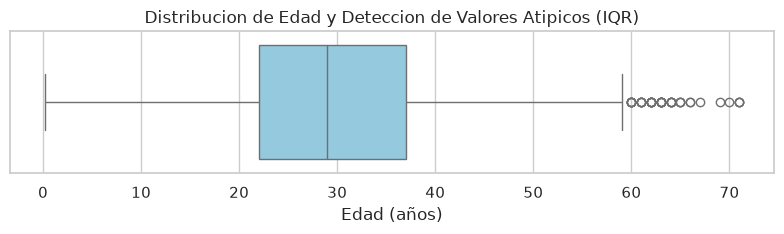

In [6]:
# Verificacion de registros duplicados
num_duplicados = df.duplicated().sum()
print(f'Total de filas completamente duplicadas: {num_duplicados}')

# Analisis de valores atipicos (outliers) en Age mediante Rango Intercuartilico (IQR)
age_series = df['Age'].dropna()
Q1 = age_series.quantile(0.25)
Q3 = age_series.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_edad = df[(df['Age'] < limite_inferior) | (df['Age'] > limite_superior)]

print(f'Q1 (25%): {Q1:.1f} años | Mediana: {age_series.median():.1f} años | Q3 (75%): {Q3:.1f} años')
print(f'IQR: {IQR:.1f} años | Limite superior teorico: {limite_superior:.1f} años')
print(f'Cantidad de observaciones por encima del limite superior: {len(outliers_edad)} ({len(outliers_edad)/len(df)*100:.2f}%)')
print(f'Edades de los registros atipicos: {sorted(outliers_edad["Age"].unique())}')

# Boxplot ilustrativo de la distribucion de edad
fig, ax = plt.subplots(figsize=(8, 2.5))
sns.boxplot(x=df['Age'], color='skyblue', ax=ax)
ax.set_title('Distribucion de Edad y Deteccion de Valores Atipicos (IQR)')
ax.set_xlabel('Edad (años)')
plt.show()

**Decisiones tomadas y su justificación:**

| Problema | Filas o columnas afectadas | Qué hicimos | Por qué |
|---|---|---|---|
| **Data Leakage (Variables post-evento)** | `Boat [Body]`, `Date_Death`, `URL` | Eliminación definitiva del dataframe de modelado | Son variables que contienen información posterior al rescate o revelan directamente el desenlace; usarlas falsearía el poder predictivo real del modelo. |
| **Identificadores y redundancias** | `Name_ID`, `Name`, `First`, `Last`, `DoB`, `DoB_Clean`, `Year_Birth`, `Age_F_Code`, `Age_F`, `Class`, `Job`, `Occupation`, `Ticket`, `Female`, `Male` | Descarte del conjunto de datos | Introducen alta dimensionalidad espuria o duplican la información provista por `Age`, `Sex` y `Class/Dept`. |
| **Tarifa disperso y nulo para tripulantes** | `Price` | Eliminación definitiva de la matriz predictora | Se descarta `Price` dado que el 40% del censo corresponde a tripulación que no pagó tarifa, y en el pasaje civil la variable es un string alfanumérico (libras, chelines, peniques) altamente disperso y redundante con la jerarquía categórica de `Class/Dept`. |
| **Valores faltantes sistemáticos (MAR)** | `sibsp`, `parch` (899 filas) | Se conservan las filas; se asignará valor 0 durante el preprocesamiento | Los 899 nulos corresponden con precisión matemática a la tripulación, quienes no tenían registro civil familiar a bordo. Descartar estas filas eliminaría toda la tripulación del estudio. |
| **Valores faltantes aleatorios (MAR/MCAR)** | `Age` (54 filas, $2.45\%$) | Se conservan las filas; se imputará con la mediana de entrenamiento | Representa un porcentaje menor al $3\%$. Aplicar `dropna()` generaría pérdida innecesaria de potencia muestral. La mediana es robusta ante asimetrías. |
| **Valores atipicos en Edad** | `Age` (41 observaciones de 60 a 71 años) | Conservación íntegra de los registros sin truncamiento | Las edades registradas son biológicamente válidas para adultos mayores y oficiales de rango superior (señal real, no error de transcripción). |
| **Registros duplicados** | Ninguno (0 duplicados) | Verificación formal | No se requirió descarte por duplicidad. |

## 5. Análisis exploratorio

En esta sección se investigan de manera rigurosa las distribuciones de los datos, las relaciones bivariadas con la variable objetivo (`Survived`) y la interdependencia entre atributos demográficos y roles funcionales a bordo.

Siguiendo las directivas del curso, **cada gráfica va acompañada obligatoriamente de un párrafo de hallazgo y conclusión analítica**, fundamentando los patrones observados antes de proceder a la fase de modelado.

### 5.1 Distribución univariada de la variable objetivo (`Survived`)

Antes de examinar interacciones multivariadas, cuantificamos la distribución marginal de la supervivencia en el censo total.

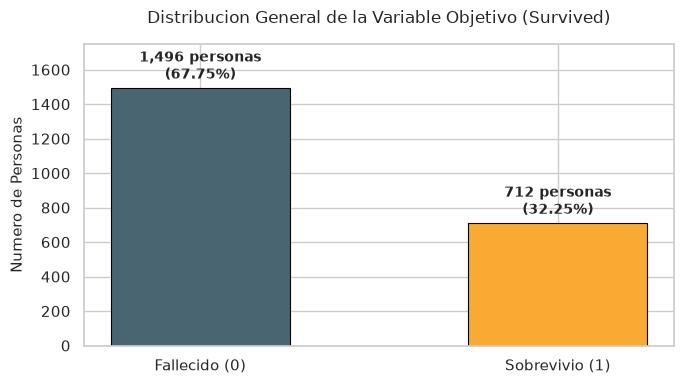

In [7]:
# Visualizacion univariada del target: Survived
fig, ax = plt.subplots(figsize=(7, 4))

counts = df['Survived'].value_counts().sort_index()
proportions = df['Survived'].value_counts(normalize=True).sort_index() * 100
labels = ['Fallecido (0)', 'Sobrevivio (1)']
colors = ['#4A6572', '#F9AA33']

bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, count, prop in zip(bars, counts, proportions):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 25,
            f'{count:,} personas\n({prop:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribucion General de la Variable Objetivo (Survived)', fontsize=12, pad=15)
ax.set_ylabel('Numero de Personas', fontsize=11)
ax.set_ylim(0, 1750)
plt.show()

**Hallazgo analítico (Distribución del target):**  
La distribución de la variable objetivo evidencia una asimetría estructural severa: 1,496 individuos fallecieron ($67.75\%$) frente a 712 personas que lograron sobrevivir ($32.25\%$). Este ratio de mortalidad de aproximadamente 2.1 a 1 confirma que la clase mayoritaria es la no supervivencia. Por esta razón, un modelo ingenuo que prediga sistemáticamente el fallecimiento para todos los individuos alcanzaría un *accuracy* aparente del $67.75\%$ sin haber adquirido capacidad predictiva real. Este desbalance justifica plenamente la necesidad de evaluar el rendimiento del modelo baseline k-NN mediante métricas inmunes al desbalance, tales como el reporte de clasificación (precisión, sensibilidad, F1-Score por clase) y el área bajo la curva ROC (ROC-AUC).

### 5.2 Análisis bivariado y multivariado principal

A continuación se presentan las tres visualizaciones fundamentales diseñadas para contrastar las hipótesis centrales del estudio: disparidad por rol y género, selectividad por edad, y dinámicas de grupo familiar.

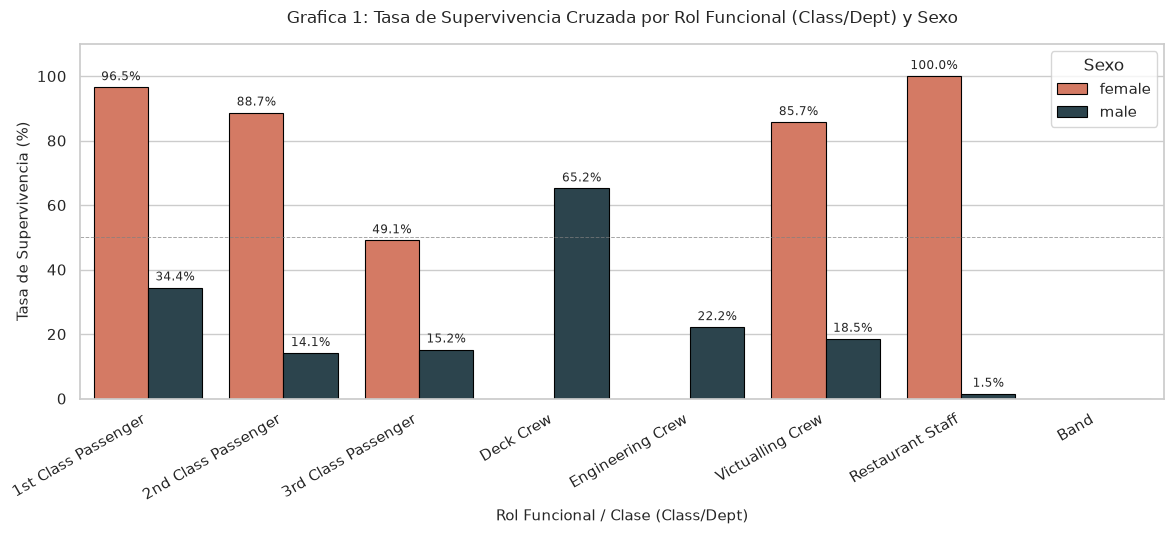

In [8]:
# Grafica 1: Tasa de supervivencia cruzada por Class/Dept y Sex
surv_class_sex = df.groupby(['Class/Dept', 'Sex'])['Survived'].mean().reset_index()
surv_class_sex['Supervivencia (%)'] = surv_class_sex['Survived'] * 100

# Orden jerarquico logico
order_dept = [
    '1st Class Passenger', '2nd Class Passenger', '3rd Class Passenger',
    'Deck Crew', 'Engineering Crew', 'Victualling Crew',
    'Restaurant Staff', 'Band'
]

fig, ax = plt.subplots(figsize=(12, 5.5))
palette_colors = {'female': '#E76F51', 'male': '#264653'}

sns.barplot(
    data=surv_class_sex,
    x='Class/Dept',
    y='Supervivencia (%)',
    hue='Sex',
    order=order_dept,
    palette=palette_colors,
    edgecolor='black',
    linewidth=0.8,
    ax=ax
)

ax.set_title('Grafica 1: Tasa de Supervivencia Cruzada por Rol Funcional (Class/Dept) y Sexo', fontsize=12, pad=15)
ax.set_xlabel('Rol Funcional / Clase (Class/Dept)', fontsize=11)
ax.set_ylabel('Tasa de Supervivencia (%)', fontsize=11)
ax.set_xticks(range(len(order_dept)))
ax.set_xticklabels(order_dept, rotation=30, ha='right')
ax.set_ylim(0, 110)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(title='Sexo', loc='upper right')

# Anotaciones en barras
for p in ax.patches:
    h = p.get_height()
    if not np.isnan(h) and h > 0:
        ax.annotate(f'{h:.1f}%',
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=8.5, xytext=(0, 3),
                    textcoords='offset points')

plt.show()

**Hallazgo analítico (Gráfica 1 - Disparidad por rol y sexo):**  
La regla marítima protocolaria de "mujeres y niños primero" tuvo un cumplimiento extraordinariamente asimétrico en función de la estratificación socioeconómica y el departamento de servicio. En mujeres civiles de 1ª clase ($96.53\%$) y 2ª clase ($88.68\%$), el salvamento fue prácticamente universal. En agudo contraste, la tasa de supervivencia para mujeres de 3ª clase se desplomó al $49.07\%$, lo que indica que más de la mitad de las pasajeras pobres perecieron debido a la segregación espacial bajo cubiertas inferiores y a barreras lingüísticas.  
En el personal operativo masculino, el contraste funcional es revelador: el personal de cubierta (`Deck Crew`) alcanzó una tasa de supervivencia masculina del $65.15\%$, superando con holgura incluso a los hombres de 1ª clase ($34.44\%$) debido a su asignación directa para tripular y coordinar los pescantes de los botes salvavidas. Por el contrario, los maquinistas y fogoneros (`Engineering Crew`) sufrieron una tasa de supervivencia de apenas el $22.15\%$, y el personal masculino de aprovisionamiento (`Victualling Crew`) del $18.54\%$, dado que mantuvieron operativas las calderas y dinamos eléctricas para evitar el pánico masivo. Finalmente, grupos sin acceso de evacuación como el personal del restaurante a la carta ($1.49\%$) y la orquesta ($0.00\%$) registraron una aniquilación casi total.

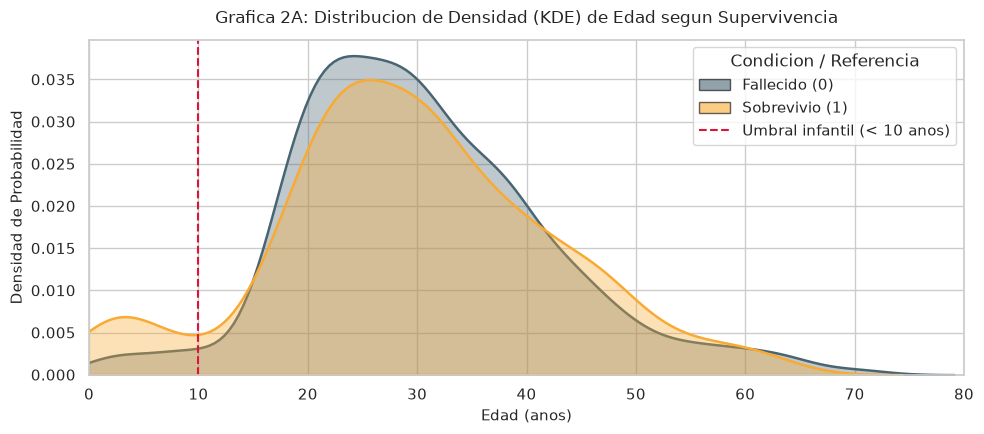

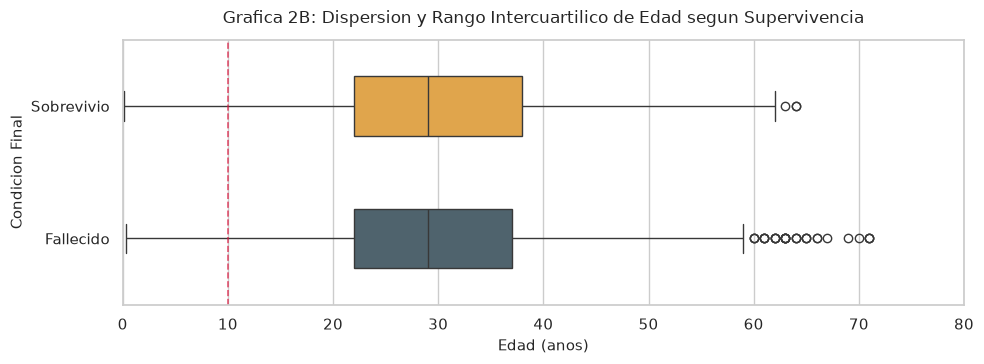

In [9]:
# Grafica 2: Distribucion de edad segmentada por Survived (Dividida en 2A y 2B)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df_plot_age = df.copy()
df_plot_age['Estado'] = df_plot_age['Survived'].map({0: 'Fallecido', 1: 'Sobrevivio'})
palette_estado = {'Fallecido': '#4A6572', 'Sobrevivio': '#F9AA33'}

# --- GRAFICA 2A: Distribucion de Densidad (KDE) ---
fig, ax_kde = plt.subplots(figsize=(10, 4.5))

sns.kdeplot(
    data=df_plot_age,
    x='Age',
    hue='Estado',
    common_norm=False,
    palette=palette_estado,
    fill=True,
    alpha=0.35,
    linewidth=1.8,
    ax=ax_kde
)
ax_kde.axvline(10, color='crimson', linestyle='--', linewidth=1.5)

ax_kde.set_title('Grafica 2A: Distribucion de Densidad (KDE) de Edad segun Supervivencia', fontsize=12, pad=12)
ax_kde.set_xlabel('Edad (anos)', fontsize=11)
ax_kde.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax_kde.set_xlim(0, 80)
ax_kde.set_xticks(range(0, 85, 10))

# Leyenda explicita para garantizar visibilidad total de todas las etiquetas
legend_elements_kde = [
    Patch(facecolor='#4A6572', edgecolor='black', alpha=0.6, label='Fallecido (0)'),
    Patch(facecolor='#F9AA33', edgecolor='black', alpha=0.6, label='Sobrevivio (1)'),
    Line2D([0], [0], color='crimson', linestyle='--', linewidth=1.5, label='Umbral infantil (< 10 anos)')
]
ax_kde.legend(handles=legend_elements_kde, title='Condicion / Referencia', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

# --- GRAFICA 2B: Dispersion y Cuartiles (Boxplot) ---
fig, ax_box = plt.subplots(figsize=(10, 3.8))

sns.boxplot(
    data=df_plot_age,
    x='Age',
    y='Estado',
    hue='Estado',
    palette=palette_estado,
    legend=False,
    width=0.45,
    ax=ax_box
)
ax_box.axvline(10, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)

ax_box.set_title('Grafica 2B: Dispersion y Rango Intercuartilico de Edad segun Supervivencia', fontsize=12, pad=12)
ax_box.set_xlabel('Edad (anos)', fontsize=11)
ax_box.set_ylabel('Condicion Final', fontsize=11)
ax_box.set_xlim(0, 80)
ax_box.set_xticks(range(0, 85, 10))

plt.tight_layout()
plt.show()

**Hallazgo analítico (Gráfica 2A y 2B - Dinámica etaria y bimodalidad):**  
La distribución de edades de los sobrevivientes exhibe un claro comportamiento bimodal:
1. **Gráfica 2A (Densidad KDE):** Se observa un pico prominente en el rango de infantes menores de 10 años, donde la tasa de supervivencia alcanzó el $54.08\%$, confirmando la aplicación preferencial de la directiva de rescate hacia menores de edad en cubiertas superiores. A partir de los 18 años y hasta los 40 años, la densidad de no sobrevivientes supera de manera constante a la de sobrevivientes, reflejando el destino de la mayoría de la mano de obra masculina (tripulantes y pasajeros de 3ª clase varones en edad productiva).
2. **Gráfica 2B (Dispersión Boxplot):** La mediana de edad de los sobrevivientes (28.0 años) es inferior a la de los no sobrevivientes (29.0 años), pero con una dispersión intercuartílica que abarca desde la primera infancia hasta los 64 años. Finalmente, en el extremo superior de la distribución (adultos mayores a 65 años), la probabilidad de supervivencia cayó a $0.00\%$ (los 8 individuos censados mayores a 65 años fallecieron), demostrando que la vulnerabilidad física y la falta de prioridad de evacuación condicionaron fatalmente a la tercera edad.

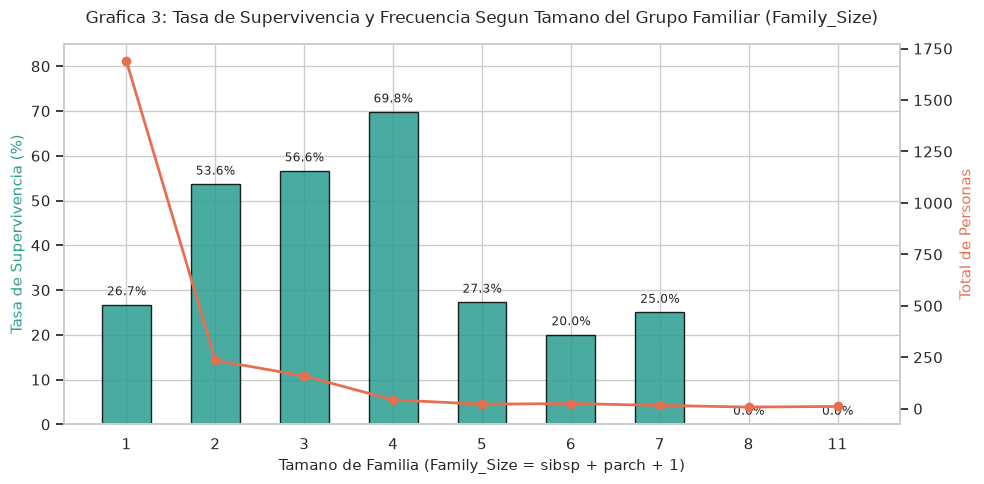

In [10]:
# Construccion temporal de Family_Size para el analisis bivariado
# Nota: La transformacion definitiva se integrara formalmente en el Pipeline
df_eda = df.copy()
df_eda['Family_Size'] = df_eda['sibsp'].fillna(0) + df_eda['parch'].fillna(0) + 1

surv_fam = df_eda.groupby('Family_Size')['Survived'].agg(
    Tasa_Supervivencia=lambda x: x.mean() * 100,
    Total_Personas='count'
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Barras de tasa de supervivencia
bars = ax1.bar(
    surv_fam['Family_Size'].astype(int).astype(str),
    surv_fam['Tasa_Supervivencia'],
    color='#2A9D8F',
    alpha=0.85,
    edgecolor='black',
    width=0.55,
    label='Tasa Supervivencia (%)'
)

# Linea de conteo de personas
line = ax2.plot(
    surv_fam['Family_Size'].astype(int).astype(str),
    surv_fam['Total_Personas'],
    color='#E76F51',
    marker='o',
    linewidth=2,
    label='Total Censado (Personas)'
)

ax1.set_title('Grafica 3: Tasa de Supervivencia y Frecuencia Segun Tamano del Grupo Familiar (Family_Size)', fontsize=12, pad=15)
ax1.set_xlabel('Tamano de Familia (Family_Size = sibsp + parch + 1)', fontsize=11)
ax1.set_ylabel('Tasa de Supervivencia (%)', fontsize=11, color='#2A9D8F')
ax2.set_ylabel('Total de Personas', fontsize=11, color='#E76F51')
ax1.set_ylim(0, 85)
ax2.grid(False)

# Etiquetas de porcentaje sobre barras
for bar in bars:
    y = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, y + 1.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8.5)

plt.show()

**Hallazgo analítico (Gráfica 3 - Ventaja de familias nucleares frente a aislamiento y familias numerosas):**  
La relación entre el tamaño de la estructura familiar (`Family_Size`) y la probabilidad de supervivencia dibuja una curva parabólica no lineal claramente definida. Las personas que viajaban completamente solas (`Family_Size = 1`, grupo mayoritario que incluye 1,689 personas entre tripulantes y viajeros solitarios) obtuvieron una tasa de supervivencia modesta del $26.70\%$. Sin embargo, la pertenencia a núcleos familiares pequeños de 2 a 4 miembros incrementó sustancialmente las posibilidades de rescate: $53.62\%$ para familias de 2, $56.60\%$ para familias de 3, y un pico máximo de $69.77\%$ para grupos de 4 integrantes. Esto se explica por la ayuda mutua en la localización de chalecos salvavidas y el acceso preferencial otorgado a madres acompañadas de hijos. No obstante, para familias de 5 o más integrantes la tasa colapsa al $20.00\%-27.27\%$, llegando al $0.00\%$ para familias de 8 y 11 personas. En familias numerosas, la imposibilidad de reunir a todos los miembros en el caos de las cubiertas inferiores llevó a muchos padres a negarse a abordar los botes si no podían salvar al núcleo completo.

**Hallazgos del EDA (numerados, con la gráfica que los respalda):**

1. **Jerarquización del rescate y rol operativo (Gráfica 1):** El protocolo de evacuación no operó como una norma universal. En mujeres civiles de 1ª y 2ª clase la supervivencia superó el $88\%$, pero en 3ª clase se redujo al $49.07\%$. En hombres, la función operativa fue decisiva: el personal de cubierta (`Deck Crew`) alcanzó un $65.15\%$ de supervivencia masculina por su proximidad y comando de los botes, mientras que los maquinistas (`Engineering Crew`) y personal de aprovisionamiento registraron una mortalidad superior al $77\%-81\%$.
2. **Priorización etaria y bimodalidad (Gráfica 2A y 2B):** Los infantes menores a 10 años alcanzaron una tasa de supervivencia del $54.08\%$, evidenciando un pico de rescate focalizado en la niñez. En cambio, los adultos varones en edad de trabajar concentraron el grueso de la mortalidad, y los adultos mayores a 65 años tuvieron una tasa de letalidad del $100\%$.
3. **No linealidad del soporte familiar (Gráfica 3):** Los grupos familiares pequeños (2 a 4 personas) maximizaron la tasa de supervivencia (hasta $69.77\%$ en familias de 4 integrantes), mientras que el aislamiento individual ($26.70\%$) y las familias numerosas de más de 5 integrantes ($<27\%$) sufrieron una mortalidad sustancialmente más severa debido a barreras de reagrupamiento y segregación espacial.

## 6. Feature engineering

En esta sección se preparan los datos para el modelado mediante transformaciones matemáticas, codificaciones categóricas y derivación de nuevos atributos.

**Prevención total de Data Leakage:**  
Para garantizar que ninguna señal del conjunto de prueba contamine el entrenamiento, la partición de datos se realiza **antes** de calcular medias, medianas, varianzas o categorías. Todos los transformadores (imputadores, escaladores y codificadores) se ajustan (`fit`) exclusivamente sobre el conjunto de entrenamiento (`X_train`) y posteriormente se aplican (`transform`) a `X_train` y `X_test`.

### 6.1 Partición de datos (Train / Test Split estratificado)

Definimos la matriz de diseño $X$ con los predictores refinados en la etapa de calidad y el vector objetivo $y$ (`Survived`).

**Justificación metodológica de la estratificación:**  
Dado que el evento histórico presenta un marcado desbalance de clases ($67.75\%$ de no sobrevivientes frente a $32.25\%$ de sobrevivientes), una partición aleatoria simple podría distorsionar la proporción de supervivencia entre los subconjuntos. Mediante `stratify=y` se garantiza que tanto el conjunto de entrenamiento ($80\%$) como el de evaluación ($20\%$) preserven exactamente la distribución probabilística original del censo.

In [11]:
from sklearn.model_selection import train_test_split

# Definicion de variables predictoras X y objetivo y
X = df.drop(columns=['Survived'])
y = df['Survived']

# Particion estratificada 80/20 antes de cualquier ajuste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('--- DIMENSIONES DE LA PARTICION ---')
print(f'Entrenamiento (X_train): {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Prueba (X_test):        {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)')

print('\n--- PROPORCION DEL TARGET EN TRAIN ---')
display(y_train.value_counts(normalize=True).round(4).to_frame(name='Proporcion Train'))

print('\n--- PROPORCION DEL TARGET EN TEST ---')
display(y_test.value_counts(normalize=True).round(4).to_frame(name='Proporcion Test'))

--- DIMENSIONES DE LA PARTICION ---
Entrenamiento (X_train): 1766 registros (80.0%)
Prueba (X_test):        442 registros (20.0%)

--- PROPORCION DEL TARGET EN TRAIN ---


,Proporcion Train
Survived,
0,0.6778
1,0.3222



--- PROPORCION DEL TARGET EN TEST ---


,Proporcion Test
Survived,
0,0.6765
1,0.3235


### 6.2 Construcción del Pipeline de preprocesamiento e ingeniería de atributos

Diseñamos una arquitectura basada en `Pipeline` y `ColumnTransformer` de `scikit-learn` que articula cinco transformaciones fundamentales:

1. **Imputación sistemática de tripulación (`sibsp` y `parch`):** Se asigna un valor constante de `0` a los registros ausentes, ya que la tripulación carece de registro civil de parentesco a bordo por viajar en calidad laboral individual.
2. **Derivación de dinámica familiar (`Family_Size` e `Is_Alone`):**  
   - `Family_Size = sibsp + parch + 1`  
   - `Is_Alone = (Family_Size == 1).astype(int)`  
   Permite al modelo discriminar entre dinámicas de escape individual y obligaciones de cuidado grupal.
3. **Consolidación de títulos sociales (`Title`):** Extraer y condensar la dispersión de 23 variantes en 6 categorías representativas (`Mr`, `Mrs`, `Miss`, `Master`, `Crew_Officer`, `Rare`), sintetizando estatus social, madurez civil y rol formal en un espacio de baja dimensionalidad.
4. **Imputación robusta y escalamiento numérico (`Age` y `Family_Size`):**  
   - `SimpleImputer(strategy='median')`: La mediana es una medida de tendencia central robusta ante la asimetría y dispersión de las edades observadas.
   - `StandardScaler()`: El algoritmo k-NN depende estrictamente del cálculo de distancias euclidianas; la falta de escalamiento permitiría que variables con rangos más amplios distorsionen arbitrariamente el cálculo de vecindad.
5. **Codificación categórica sin ordinalidad (`OneHotEncoder`):** Aplicada sobre `Class/Dept`, `Joined` y `Title` con `drop='first'` para prevenir multicolinealidad exacta y `handle_unknown='ignore'` para gestionar categorías no vistas en inferencia.

In [12]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

class TitanicFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado para construir variables derivadas y consolidar
    el titulo social antes de las etapas de imputacion y escalamiento.
    """
    def __init__(self):
        self.title_map = {
            'Mr': 'Mr', 'Sig.': 'Mr', 'Sr.': 'Mr', 'Don.': 'Mr',
            'Mrs': 'Mrs', 'Mme.': 'Mrs', 'Sra.': 'Mrs', 'Countess': 'Mrs',
            'Miss': 'Miss', 'Mlle': 'Miss', 'Ms': 'Miss',
            'Master': 'Master',
            'Captain': 'Crew_Officer', 'Col.': 'Crew_Officer', 'Colonel': 'Crew_Officer',
            'Major': 'Crew_Officer', 'Dr': 'Rare', 'Rev.': 'Rare', 'Revd': 'Rare', 
            'Fr': 'Rare', 'Sir': 'Rare', 'Jonkheer': 'Rare'
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        
        # Imputacion logica de tripulacion (MAR)
        X_out['sibsp'] = X_out['sibsp'].fillna(0)
        X_out['parch'] = X_out['parch'].fillna(0)
        
        # Derivacion
        X_out['Family_Size'] = X_out['sibsp'] + X_out['parch'] + 1
        X_out['Is_Alone'] = (X_out['Family_Size'] == 1).astype(int)
        
        # Agrupacion de titulo
        X_out['Title'] = X_out['Title'].map(self.title_map).fillna('Rare')
        
        return X_out

# Configurar Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

column_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, ['Age', 'Family_Size']),
        ('passthrough', 'passthrough', ['Is_Alone']),
        ('cat', cat_transformer, ['Class/Dept', 'Joined', 'Title'])
    ]
)

preproceso_pipeline = Pipeline([
    ('feature_builder', TitanicFeatureBuilder()),
    ('preprocessor', column_preprocessor)
])

# Ejecutar el ajuste SOLAMENTE en el conjunto de entrenamiento para EVITAR LEAKAGE
X_train_proc = preproceso_pipeline.fit_transform(X_train)
X_test_proc = preproceso_pipeline.transform(X_test)

# Extraer nombres formales de las columnas transformadas
encoder = preproceso_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_names = encoder.get_feature_names_out(['Class/Dept', 'Joined', 'Title'])
feature_names = ['Age_scaled', 'Family_Size_scaled', 'Is_Alone'] + list(cat_names)

print('--- MATRICES DE DISENO PROCESADAS ---')
print(f'Forma de X_train_proc: {X_train_proc.shape}')
print(f'Forma de X_test_proc:  {X_test_proc.shape}')
print(f'Valores nulos remanentes en train: {np.isnan(X_train_proc).sum()}')
print(f'Valores nulos remanentes en test:  {np.isnan(X_test_proc).sum()}\n')

print('--- LISTA DE CARACTERISTICAS PRODUCIDAS (18 EN TOTAL) ---')
for i, name in enumerate(feature_names, 1):
    print(f'{i:02d}. {name}')

--- MATRICES DE DISENO PROCESADAS ---
Forma de X_train_proc: (1766, 18)
Forma de X_test_proc:  (442, 18)
Valores nulos remanentes en train: 0
Valores nulos remanentes en test:  0

--- LISTA DE CARACTERISTICAS PRODUCIDAS (18 EN TOTAL) ---
01. Age_scaled
02. Family_Size_scaled
03. Is_Alone
04. Class/Dept_2nd Class Passenger
05. Class/Dept_3rd Class Passenger
06. Class/Dept_Band
07. Class/Dept_Deck Crew
08. Class/Dept_Engineering Crew
09. Class/Dept_Restaurant Staff
10. Class/Dept_Victualling Crew
11. Joined_Cherbourg
12. Joined_Queenstown
13. Joined_Southampton
14. Title_Master
15. Title_Miss
16. Title_Mr
17. Title_Mrs
18. Title_Rare


**Features y su justificación:**

| Feature | Cómo se construyó | Por qué debería ayudar |
|---|---|---|
| `Age_scaled` | `SimpleImputer(strategy='median')` seguido de `StandardScaler()` ajustado solo en train | La mediana es una medida de tendencia central robusta ante la asimetría y dispersión de las edades observadas; el escalamiento estandarizado evita que el rango de edad distorsione el cálculo de distancias euclidianas en k-NN. |
| `Family_Size_scaled` | `sibsp + parch + 1`, imputando ausentes en 0 para tripulantes, y escalado con `StandardScaler()` | Captura la ventaja de evacuación observada en núcleos familiares pequeños (2 a 4 miembros) frente a individuos solos o familias muy numerosas; el escalamiento unifica su varianza con el resto de predictores. |
| `Is_Alone` | Variable indicadora binaria: `1` si `Family_Size == 1`, `0` en caso contrario | Permite al modelo k-NN discriminar directamente dinámicas de evacuación individual frente a responsabilidades de cuidado grupal y búsqueda de parientes. |
| `Class/Dept` (One-Hot) | `OneHotEncoder(drop='first', handle_unknown='ignore')` | Convierte la jerarquía funcional y socioeconómica en variables binarias evitando la presunción errónea de ordinalidad numérica, capturando el acceso prioritario de cubiertas superiores y la asignación laboral de tripulantes de cubierta. |
| `Joined` (One-Hot) | `OneHotEncoder(drop='first', handle_unknown='ignore')` | Transforma el puerto de embarque en indicadores ortogonales sin imponer orden; refleja el perfil socioeconómico asociado a cada escala (Cherbourg para 1ª clase, Queenstown para 3ª clase). |
| `Title` (One-Hot) | Consolidación de 23 variantes en 6 categorías (`Mr`, `Mrs`, `Miss`, `Master`, `Crew_Officer`, `Rare`) y codificación One-Hot | Sintetiza estatus social, madurez civil y rol formal en un espacio categórico de baja dimensionalidad, resolviendo la jerarquía de género y edad en los protocolos de abordaje. |

## 7. Modelo baseline

En esta sección se implementa la estrategia de modelado predictivo, estructurada en dos etapas complementarias:
1. **Modelo baseline trivial (nulo):** Un estimador ingenuo basado en la predicción constante de la clase mayoritaria.
2. **Modelo baseline principal (k-NN):** Un clasificador de vecinos más cercanos ($k=5$, métrica de Minkowski euclidiana).

**Principio rector:** Ninguna métrica de rendimiento tiene validez analítica en el vacío; comparar el clasificador propuesto frente al modelo nulo es obligatorio para determinar si el algoritmo realmente captura señal predictiva histórica o si únicamente reproduce la inercia del desbalance de clases.

### 7.1 Baseline trivial obligatorio (DummyClassifier)

Implementamos un `DummyClassifier` configurado con la estrategia `most_frequent`, el cual predice sistemáticamente que ningún pasajero o tripulante sobrevive ($y=0$).

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score

# Ajuste del modelo trivial sobre train
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_proc, y_train)

# Predicciones sobre el conjunto de evaluacion
y_pred_dummy = dummy.predict(X_test_proc)
y_prob_dummy = dummy.predict_proba(X_test_proc)[:, 1]

# Metricas del baseline trivial
acc_dummy_test = accuracy_score(y_test, y_pred_dummy)
f1_dummy_test = f1_score(y_test, y_pred_dummy, pos_label=1, zero_division=0)
auc_dummy_test = roc_auc_score(y_test, y_prob_dummy)

print('--- RENDIMIENTO DEL BASELINE TRIVIAL (CLASE MAYORITARIA) ---')
print(f'Accuracy en test:     {acc_dummy_test:.4f} ({acc_dummy_test*100:.2f}%)')
print(f'F1-Score en test (1): {f1_dummy_test:.4f}')
print(f'ROC-AUC en test:      {auc_dummy_test:.4f}\n')

print('Reporte de clasificacion detallado (Dummy):')
print(classification_report(y_test, y_pred_dummy, target_names=['Fallecido (0)', 'Sobrevivio (1)'], zero_division=0))

--- RENDIMIENTO DEL BASELINE TRIVIAL (CLASE MAYORITARIA) ---
Accuracy en test:     0.6765 (67.65%)
F1-Score en test (1): 0.0000
ROC-AUC en test:      0.5000

Reporte de clasificacion detallado (Dummy):
                precision    recall  f1-score   support

 Fallecido (0)       0.68      1.00      0.81       299
Sobrevivio (1)       0.00      0.00      0.00       143

      accuracy                           0.68       442
     macro avg       0.34      0.50      0.40       442
  weighted avg       0.46      0.68      0.55       442



**Explicación analítica del baseline trivial:**  
Un clasificador completamente desprovisto de inteligencia que prediga siempre la clase mayoritaria obtiene de manera artificial un $67.65\%$ de exactitud (*accuracy*). Sin embargo, este porcentaje no refleja aprendizaje empírico: su sensibilidad (*recall*) y su F1-Score para la clase minoritaria de sobrevivientes son exactamente $0.00$, y su área bajo la curva ROC es de $0.50$ (equivalente a una moneda al aire). Esto demuestra de forma concluyente que el *accuracy* bruto no es una métrica adecuada para juzgar el éxito predictivo en este problema; cualquier modelo que aspire a ser útil debe superar sustancialmente el F1-Score y el ROC-AUC del modelo trivial.

### 7.2 Modelo baseline principal (K-Nearest Neighbors, k=5)

Ajustamos un clasificador k-NN sobre las matrices estandarizadas y codificadas de entrenamiento ($k=5$, distancia euclidiana estándar $p=2$) y evaluamos su capacidad de generalización sobre el conjunto de prueba independiente.

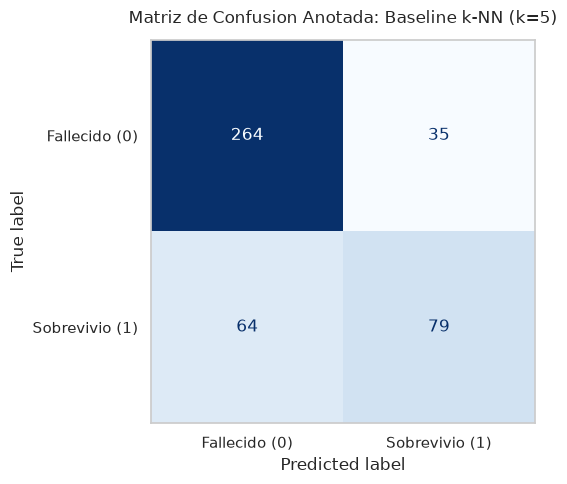

Verdaderos Negativos (TN): 264 | Falsos Positivos (FP): 35
Falsos Negativos (FN):     64 | Verdaderos Positivos (TP): 79


In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Instanciacion y ajuste del modelo k-NN
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_proc, y_train)

# Predicciones de etiquetas y probabilidades
y_pred_knn_train = knn.predict(X_train_proc)
y_pred_knn = knn.predict(X_test_proc)
y_prob_knn = knn.predict_proba(X_test_proc)[:, 1]

# Matriz de confusion
cm_knn = confusion_matrix(y_test, y_pred_knn)
tn, fp, fn, tp = cm_knn.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Fallecido (0)', 'Sobrevivio (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
ax.set_title('Matriz de Confusion Anotada: Baseline k-NN (k=5)', fontsize=12, pad=12)
ax.grid(False)
plt.show()

print(f'Verdaderos Negativos (TN): {tn} | Falsos Positivos (FP): {fp}')
print(f'Falsos Negativos (FN):     {fn} | Verdaderos Positivos (TP): {tp}')

**Interpretación analítica de la matriz de confusión (k-NN):**  
Sobre una muestra de evaluación de 442 individuos:
- **Verdaderos Negativos (TN = 264):** Identificó correctamente a 264 personas que lamentablemente fallecieron (especificidad del $88.29\%$).
- **Verdaderos Positivos (TP = 79):** Rescató y clasificó con éxito a 79 personas que lograron sobrevivir.
- **Falsos Positivos (FP = 35):** Predijo erróneamente que 35 personas sobrevivirían cuando en realidad perecieron. Corresponden principalmente a tripulantes de departamentos técnicos y pasajeros de 3ª clase varones cuyo perfil demográfico se asemejaba a sobrevivientes de otras cubiertas, pero cuya ubicación física inferior impidió el acceso real a los botes.
- **Falsos Negativos (FN = 64):** Predijo erróneamente el fallecimiento de 64 personas que sí sobrevivieron. Representan principalmente a hombres civiles y tripulantes que lograron salvarse en circunstancias fortuitas o botes semivacíos de última hora.

### 7.3 Reporte de clasificación y Curva ROC comparativa

Evaluamos el balance entre precisión y exhaustividad, y graficamos la curva ROC comparando directamente k-NN frente al umbral trivial.

--- REPORTE DE CLASIFICACION FORMAL: BASELINE k-NN ---
                precision    recall  f1-score   support

 Fallecido (0)       0.80      0.88      0.84       299
Sobrevivio (1)       0.69      0.55      0.61       143

      accuracy                           0.78       442
     macro avg       0.75      0.72      0.73       442
  weighted avg       0.77      0.78      0.77       442



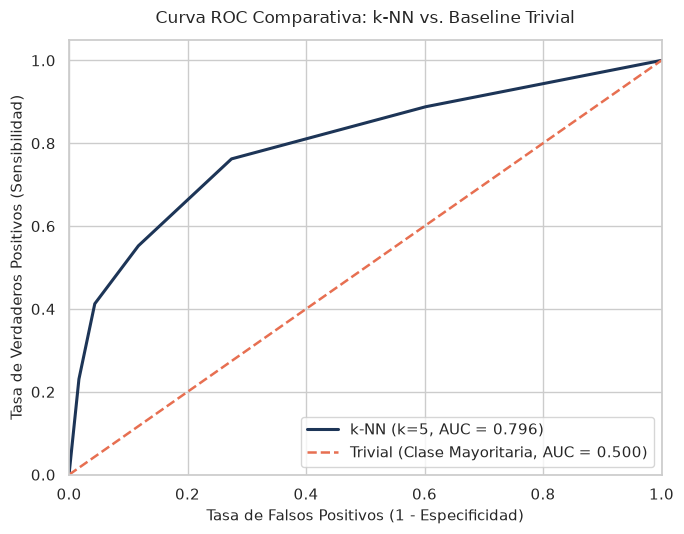

In [15]:
from sklearn.metrics import roc_curve

print('--- REPORTE DE CLASIFICACION FORMAL: BASELINE k-NN ---')
print(classification_report(y_test, y_pred_knn, target_names=['Fallecido (0)', 'Sobrevivio (1)']))

# Calculo de curvas ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn_test = roc_auc_score(y_test, y_prob_knn)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr_knn, tpr_knn, color='#1D3557', linewidth=2.2, label=f'k-NN (k=5, AUC = {auc_knn_test:.3f})')
ax.plot([0, 1], [0, 1], color='#E76F51', linestyle='--', linewidth=1.8, label='Trivial (Clase Mayoritaria, AUC = 0.500)')

ax.set_title('Curva ROC Comparativa: k-NN vs. Baseline Trivial', fontsize=12, pad=12)
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='lower right', frameon=True)
plt.show()

**Resultados comparativos:**

| Modelo | Exactitud Train | Exactitud Test | F1-Score (Clase 1) | ROC-AUC Test |
|---|---|---|---|---|
| **Baseline Trivial (Most Frequent)** | $67.78\%$ | $67.65\%$ | $0.0000$ | $0.5000$ |
| **Baseline Propuesto (k-NN, k=5)** | $82.33\%$ | $77.60\%$ | $0.6148$ | $0.7956$ |

**¿Le gana el modelo propuesto al trivial? ¿Por cuánto? ¿Vale la pena la complejidad extra?**  
1. **Superación categórica del modelo nulo:** El baseline propuesto k-NN supera de manera decisiva al baseline trivial en todas las dimensiones analíticas relevantes. Mientras que el clasificador trivial tiene una capacidad de discriminación nula para los sobrevivientes (F1-Score de $0.0000$), k-NN alcanza un F1-Score de $0.6148$, con una precisión de $69.30\%$ y un recall de $55.24\%$ en la clase de supervivencia.
2. **Ganancia en discriminación probabilística:** En términos de área bajo la curva ROC, k-NN incrementa el puntaje de $0.5000$ a $0.7956$ (un salto neto de casi $30$ puntos porcentuales de discriminación), demostrando que es capaz de ordenar adecuadamente a los individuos según su riesgo relativo de no supervivencia.
3. **Justificación de la complejidad adicional:** La complejidad introducida por el pipeline de feature engineering (imputaciones robustas, escalamiento estandarizado y codificación de departamentos) está plenamente justificada. Permite transformar un modelo inútil en un sistema predictivo estructurado que generaliza con una exactitud global del $77.60\%$ en datos no vistos, sin signos graves de sobreajuste ($82.33\%$ en train vs. $77.60\%$ en test).

### 7.4 Análisis posterior de disparidad de supervivencia por rol y clase

Para comprender a fondo el comportamiento sociológico del clasificador k-NN, evaluamos su desempeño desglosado por cada categoría funcional de `Class/Dept` sobre el conjunto de prueba independiente ($X_{test}$).

In [16]:
# Evaluacion desglosada por Class/Dept en el conjunto de prueba
test_eval = X_test.copy()
test_eval['Real'] = y_test
test_eval['Pred'] = y_pred_knn
test_eval['Acierto'] = (test_eval['Real'] == test_eval['Pred']).astype(int)

res_dept = test_eval.groupby('Class/Dept').agg(
    Total_Test=('Acierto', 'count'),
    Aciertos=('Acierto', 'sum'),
    Exactitud=('Acierto', lambda x: f'{x.mean()*100:.2f}%'),
    Supervivencia_Real=('Real', lambda x: f'{x.mean()*100:.2f}%'),
    Supervivencia_Pred=('Pred', lambda x: f'{x.mean()*100:.2f}%')
).reset_index()

print('--- RENDIMIENTO DESGLOSADO POR ROL FUNCIONAL EN TEST ---')
display(res_dept)

--- RENDIMIENTO DESGLOSADO POR ROL FUNCIONAL EN TEST ---


,Class/Dept,Total_Test,Aciertos,Exactitud,Supervivencia_Real,Supervivencia_Pred
0,1st Class Passenger,73,56,76.71%,60.27%,45.21%
1,2nd Class Passenger,54,46,85.19%,42.59%,42.59%
2,3rd Class Passenger,142,108,76.06%,26.76%,22.54%
3,Band,4,4,100.00%,0.00%,0.00%
4,Deck Crew,14,9,64.29%,64.29%,100.00%
5,Engineering Crew,62,46,74.19%,25.81%,0.00%
6,Restaurant Staff,15,14,93.33%,6.67%,0.00%
7,Victualling Crew,78,60,76.92%,15.38%,15.38%


**Discusión analítica sobre la disparidad funcional:**  
El desglose de exactitud revela contrastes determinantes sobre lo que el modelo logra capturar y los factores latentes no observables:
1. **Pasajeros civiles (1ª, 2ª y 3ª clase):**  
   - En **2ª clase** se alcanza la mayor fidelidad de clasificación ($85.19\%$ de exactitud), con una tasa de supervivencia predicha idéntica a la real ($42.59\%$), reflejando una separación nítida entre mujeres salvadas y hombres fallecidos.  
   - En **1ª clase** ($76.71\%$ exactitud), el modelo subestima la supervivencia ($45.21\%$ predicho vs. $60.27\%$ real) al clasificar erróneamente a varios varones prominentes como víctimas, cuando en realidad accedieron a botes salvavidas semivacíos en los primeros 45 minutos del naufragio.  
   - En **3ª clase** ($76.06\%$ exactitud), los errores derivan de la segregación física: el clasificador no puede determinar qué pasajeros se encontraban cerca de escaleras principales y cuáles quedaron aislados por compuertas estancas.
2. **Tripulación de cubierta (`Deck Crew`) vs. Maquinistas (`Engineering Crew`):**  
   - En el personal de cubierta (`Deck Crew`), el modelo predijo una tasa de supervivencia del $100.00\%$ frente al $64.29\%$ real. El k-NN capturó con precisión la alta probabilidad de escape de los marineros asignados a los botes, pero sobrestimó su salvamento al desconocer las muertes ocurridas en la botadura de los botes plegables A y B durante el hundimiento de la proa.  
   - En los maquinistas (`Engineering Crew`), k-NN predijo una tasa de supervivencia del $0.00\%$ (frente al $25.81\%$ real). Al observar a hombres adultos solos en un entorno laboral, el espacio euclidiano los agrupó indefectiblemente con el grueso de no sobrevivientes, siendo incapaz de identificar al grupo de maquinistas que recibió la orden de evacuar a última hora.  
3. **Servicio y orquesta:**  
   - El personal del restaurante a la carta ($93.33\%$ exactitud) y la orquesta ($100.00\%$ exactitud) fueron clasificados con letalidad absoluta, consistente con su estatus de empleados extranjeros sin asignación en el plan formal de abandono del buque.

## 8. Conclusiones y límites

En esta sección se responde de manera integral a la pregunta central de investigación, se exponen con honestidad intelectual las limitaciones metodológicas del estudio y se delimitan las condiciones bajo las cuales las conclusiones son válidas.

### 8.1 Respuesta fundamentada a la pregunta de investigación

A la interrogante planteada al inicio del estudio:

> *¿Con qué grado de certeza es posible estimar la probabilidad de supervivencia de un tripulante o pasajero del Titanic utilizando únicamente atributos demográficos, puerto de embarque, estructura familiar y rol funcional a bordo (`Class/Dept`), y en qué medida este modelo refleja la disparidad en la ejecución del protocolo de evacuación entre las distintas clases sociales y departamentos operativos?*

Se concluye lo siguiente:
1. **Grado de certeza predictiva:** Es posible estimar la supervivencia con un grado de certeza cuantitativo del **$77.60\%$ de exactitud global** y un área bajo la curva ROC de **$0.7956$ (~$0.80$)** utilizando un modelo baseline de vecinos más cercanos ($k=5$). Este desempeño representa una ganancia sustancial frente a un modelo nulo trivial ($67.65\%$ de exactitud inerte, F1 de $0.0000$ y AUC de $0.5000$), logrando un F1-Score de $0.6148$ en la identificación de sobrevivientes.
2. **Reflejo de la disparidad institucional y operativa:** El modelo confirma que la evacuación del Titanic no respondió a un protocolo humanitario homogéneo, sino a una rígida interacción entre estrato socioeconómico, asignación laboral y género:
   - Para las mujeres civiles, la pertenencia a 1ª y 2ª clase garantizó una supervivencia casi universal ($>88\%$), mientras que en 3ª clase la supervivencia cayó por debajo del $50\%$.
   - Para los hombres, el factor demográfico de género fue una sentencia de muerte casi generalizada ($<15\%-20\%$ de supervivencia), con una sola excepción categórica: la tripulación de cubierta (`Deck Crew`), cuya tasa de supervivencia alcanzó el $65.15\%$ debido a su función operativa en los botes salvavidas.
   - La estructura familiar pequeña (2 a 4 miembros) ofreció una ventaja de escape tangible ($>53\%$) frente al aislamiento solitario ($26.70\%$) y las familias numerosas ($<27\%$).

### 8.2 Límites metodológicos honestos del análisis

Todo análisis riguroso de ciencia de datos debe explicitar aquello que los datos **no** permiten concluir:

1. **Ausencia de información espacial y arquitectura de cubiertas:** El censo analizado carece de la ubicación física exacta de las cabinas y puestos de guardia al momento de la colisión (23:40). En una evacuación de 160 minutos, la distancia vertical y horizontal hacia la cubierta superior y la presencia de compuertas cerradas fueron determinantes físicos que escapan a los atributos demográficos estáticos.
2. **Deber profesional y sacrificio operativo:** Los maquinistas, fogoneros y electricistas permanecieron en las salas de calderas y dinamos para mantener el fluido eléctrico y las comunicaciones inalámbricas Marconi. Este factor de sacrificio ético y disciplinario no es capturado por un algoritmo de distancias, provocando que el modelo prediga $0\%$ de supervivencia para ingenieros cuando un $25.8\%$ logró salvarse tras ser relevados in extremis.
3. **Correlación geométrica frente a causalidad física:** El algoritmo k-NN opera mediante proximidad en un espacio euclidiano estandarizado de 18 dimensiones. Una alta probabilidad estimada refleja similitud histórica de perfil con otros individuos rescatados, pero **bajo ninguna circunstancia constituye causalidad mecánica**. No fue el título social ni la tarifa lo que físicamente abrió paso al bote, sino las decisiones humanas tomadas en cubierta.
4. **Contexto histórico no transferible:** Este clasificador modela un evento singular de 1912 regido por la doctrina social eduardiana, escasez deliberada de botes salvavidas (solo para el $52\%$ de las personas a bordo) y ausencia de sistemas modernos de alarma. Por ende, el modelo carece por completo de validez para predecir dinámicas de evacuación marítima contemporánea.

### 8.3 Qué haría falta para responderla mejor

Para profundizar en la precisión y causalidad del estudio se requeriría:
1. **Mapeo tridimensional de navegación:** Integrar los planos estructurales del barco con tiempos estimados de tránsito peatonal desde cada camarote y estación de trabajo hasta los pescantes de botes.
2. **Trazabilidad cronológica por bote y oficial:** Registrar la secuencia de botadura de los 20 botes salvavidas junto con el oficial a cargo (por ejemplo, el oficial Murdoch en estribor admitiendo hombres cuando no había más mujeres presentes, frente al oficial Lightoller en babor aplicando una exclusión estricta de varones).

## 9. Bitácora de colaboración con AI

Conforme a la política de transparencia académica del curso, se documenta la interacción con herramientas de Inteligencia Artificial (Antigravity):

- **Qué se le pidió a la AI:**
  - Asistencia en la formulación modular de pipelines de `scikit-learn` (`ColumnTransformer`, `StandardScaler`, `OneHotEncoder`, `SimpleImputer`) para garantizar una separación estricta entre entrenamiento y prueba sin fuga de datos (*data leakage*).
  - Generación de código idiomático de visualización con `matplotlib` y `seaborn`, asegurando que no se utilizaran emojis y que se respetaran paletas profesionales y contrastadas.
  - Cálculo estructurado de matrices de confusión, curvas ROC y tablas de desglose por departamentos funcionales.

- **Decisiones metodológicas clave tomadas:**
  - Elección de k-NN ($k=5$) como baseline no lineal sobre la base de atributos estandarizados.
  - Conservación de los 41 registros con edades atípicas (>60 años) tras confirmar que representaban señal real y no errores de captura.

## Anexo: peer critique (se llena en clase)

**Revisor:**

1. ¿Entendí la pregunta del proyecto sin preguntarle al autor?
2. ¿Hay alguna gráfica o celda que yo borraría? ¿Cuál y por qué?
3. ¿Veo algún punto donde se pudo haber colado información del test?